Chapter 4 - Results

Sections 4.3-4.4

Plots: Raman Proxies and Infered Model Proxies vs Growth rate. Active ribosomes vs growth rate. Statistical and quantitative analysis.

Investigating ribosome allocation dynamics revealed by the proposed proxies and assess their reliability as structural and/or functional ribosome allocation proxies.

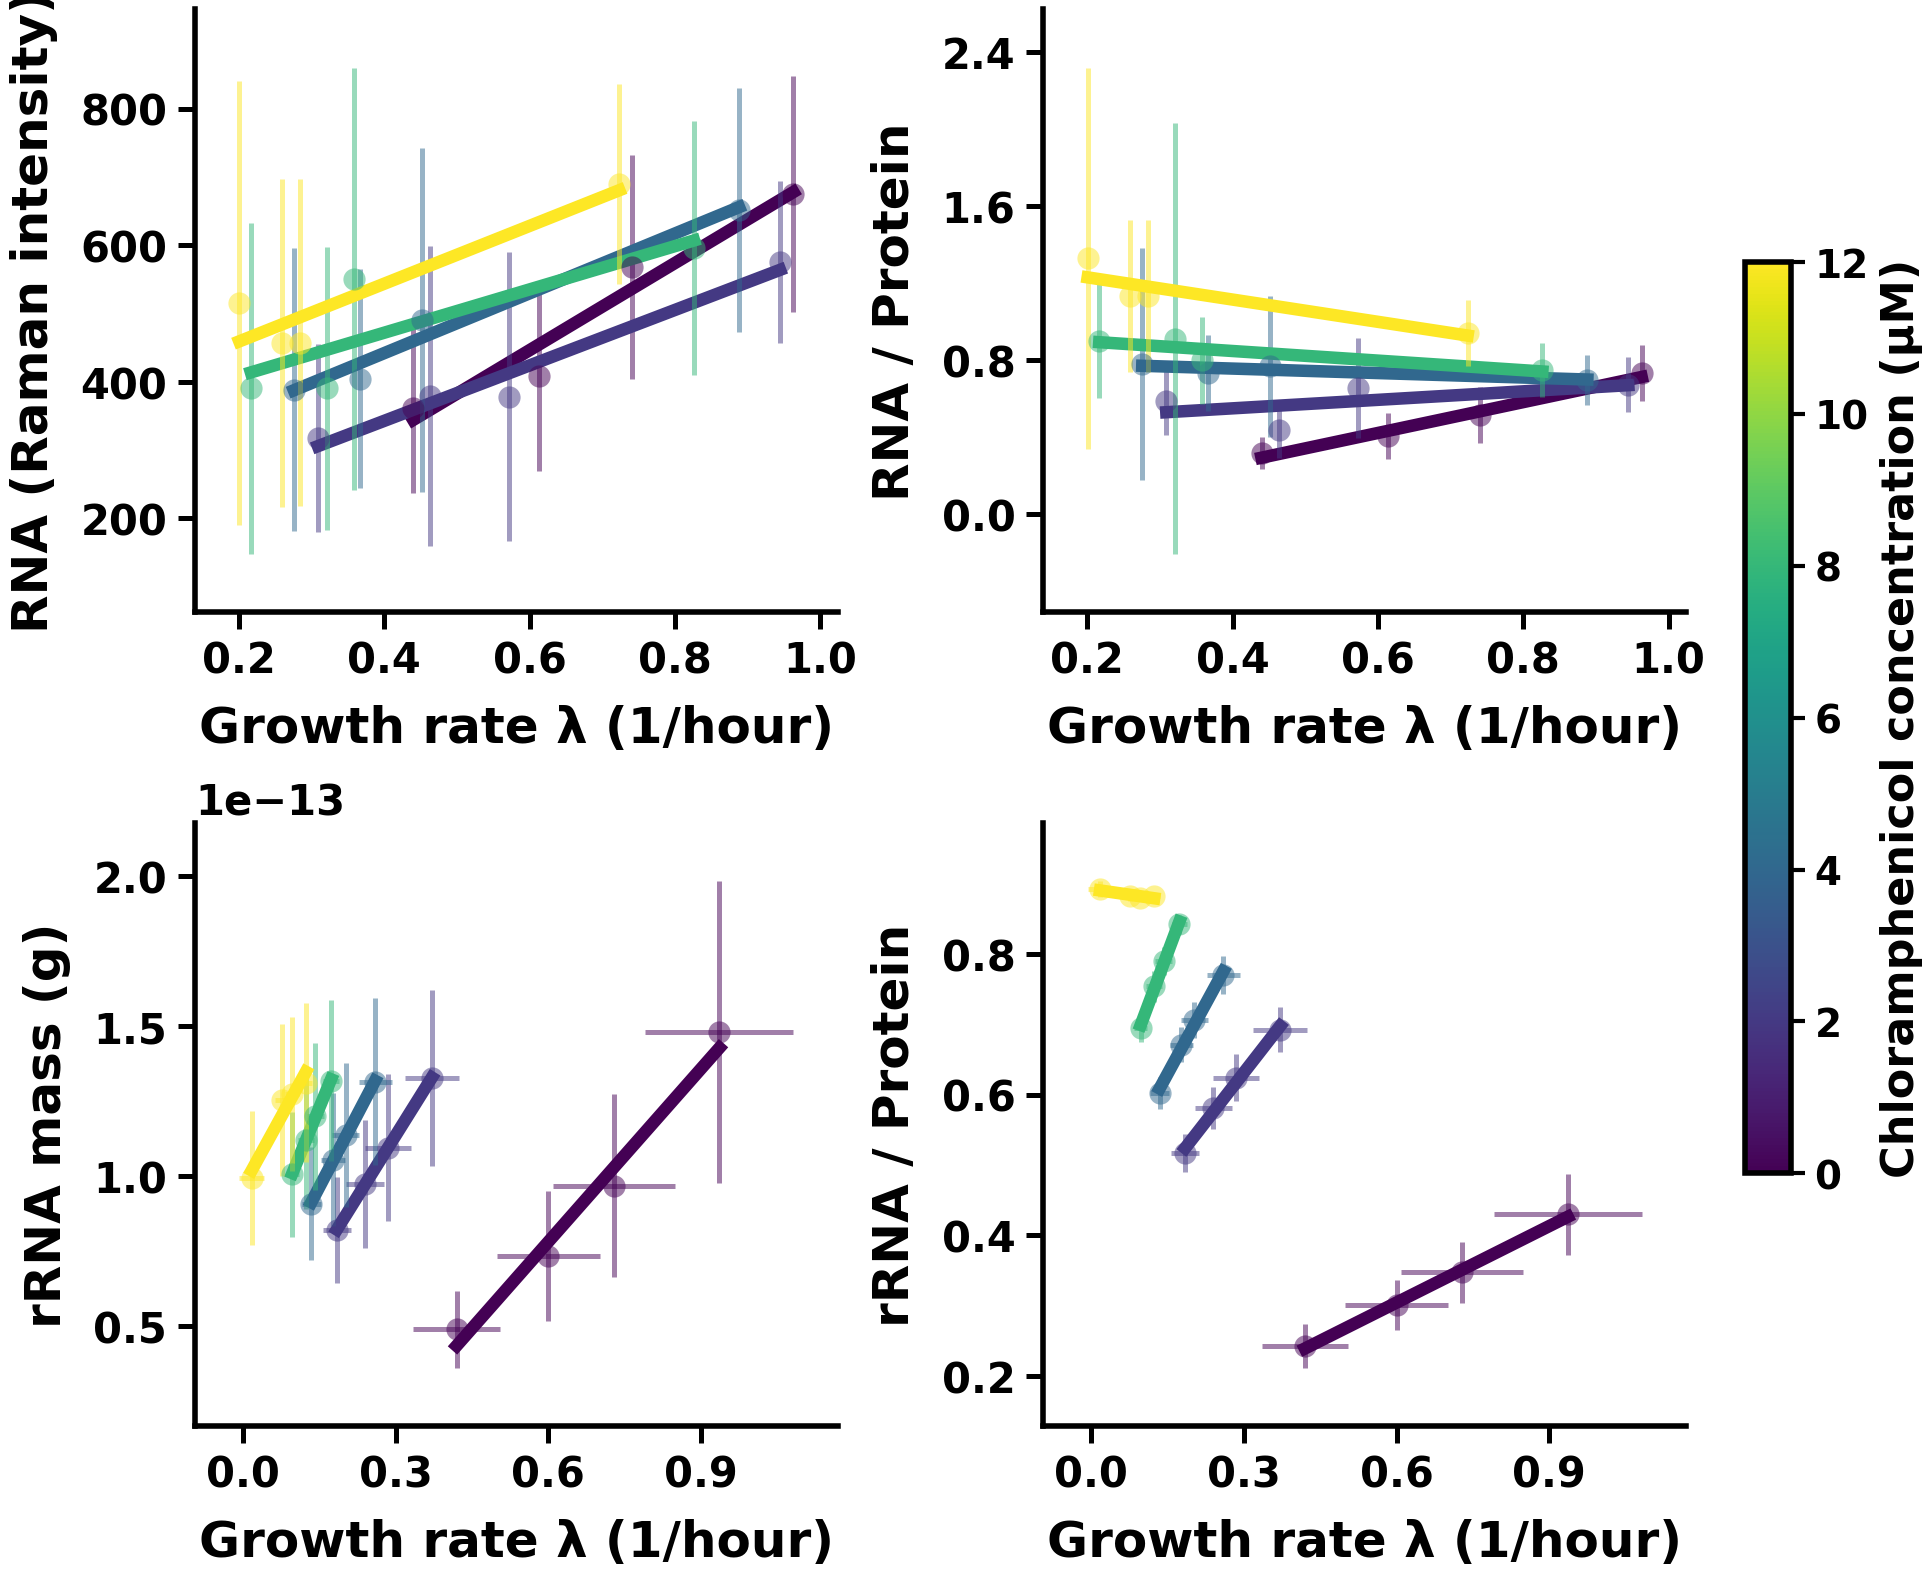

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pyarrow as pa
import pyarrow.ipc as ipc
from matplotlib.ticker import MaxNLocator

plt.style.use("default")
plt.rcParams['font.weight'] = 'bold'
plt.rcParams.update({
    "figure.figsize": (10.5, 9.5),
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "axes.linewidth": 2.0,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "lines.linewidth": 4.5,
    "lines.markersize": 8,
    "errorbar.capsize": 4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05
})

NS_VALUES = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

BURN_IN = 1000.0

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 330.0

GMAX = 12600.0
KGAMMA = 7 * 22000

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_rRNA_mass(df):
    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()
    total_nt = r_tot * RIBO_RNA_NT
    return (total_nt / AVOGADRO) * MW_NT

def compute_protein_mass(df):
    r = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_aa = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_aa = NX * (q + et + em)
    total_aa = ribo_aa + non_ribo_aa
    return (total_aa / AVOGADRO) * MW_AA

def compute_total_mass(df):
    r = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_total = r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr
    ribo_mass = NR * ribo_total
    non_ribo = NX * (q + et + em)
    return ribo_mass + non_ribo

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return (active * gamma / total_mass) * 60.0

model_records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:
        path = f"../Data/ns{int(ns*100):03d}/abx{abx}.arrow"
        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        rRNA = compute_rRNA_mass(df)
        protein = compute_protein_mass(df)
        total_mass = compute_total_mass(df)
        lam = compute_growth(df, total_mass)
        ratio = rRNA / protein

        model_records.append({
            "ns": ns,
            "abx": abx,
            "lambda_mean": np.mean(lam),
            "lambda_sd": np.std(lam),
            "rRNA_mean": np.mean(rRNA),
            "rRNA_sd": np.std(rRNA),
            "ratio_mean": np.mean(ratio),
            "ratio_sd": np.std(ratio)
        })

df_model = pd.DataFrame(model_records)

rna_df = pd.read_csv("../Data/RamanData/rna.csv")
protein_df = pd.read_csv("../Data/RamanData/protein.csv")
growth_df = pd.read_csv("../Data/RamanData/Raman_growth.csv")

raman_records = []

for nutrient in growth_df["Condition"].unique():
    for abx in ABX_VALUES:
        col = f"Cm{abx}_{nutrient}"

        if col not in rna_df.columns:
            continue

        RNA = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        valid = (RNA > 0) & (PROT > 0)
        RNA = RNA[valid]
        PROT = PROT[valid]

        if len(RNA) == 0:
            continue

        ratio = RNA / PROT

        mu = growth_df[
            (growth_df["Condition"] == nutrient) &
            (growth_df["Dose"] == abx)
        ]["Value"].values[0]

        raman_records.append({
            "nutrient": nutrient,
            "abx": abx,
            "lambda_mean": mu,
            "lambda_sd": 0.0,
            "RNA_mean": np.mean(RNA),
            "RNA_sd": np.std(RNA),
            "ratio_mean": np.mean(ratio),
            "ratio_sd": np.std(ratio)
        })

df_raman = pd.DataFrame(raman_records)

norm = mcolors.Normalize(vmin=min(ABX_VALUES), vmax=max(ABX_VALUES))
cmap = cm.viridis

def finish_axes(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, labelpad=8, weight='bold')
    ax.set_ylabel(ylabel, labelpad=8, weight='bold')
    ax.tick_params(direction="out", length=6, width=1.8, pad=4)
    ax.margins(x=0.08, y=0.12)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

def add_panel(ax, df, xmean_col, xsd_col, ymean_col, ysd_col, ylabel):
    for abx in ABX_VALUES:
        subset = df[df["abx"] == abx].sort_values(xmean_col)

        x = subset[xmean_col].values
        y = subset[ymean_col].values
        xerr = subset[xsd_col].values
        yerr = subset[ysd_col].values

        if len(x) < 2:
            continue

        color = cmap(norm(abx))

        ax.errorbar(
            x,
            y,
            xerr=xerr,
            yerr=yerr,
            fmt="o",
            color=color,
            elinewidth=1.8,
            capthick=1.8,
            markeredgewidth=0,
            alpha=0.5
        )

        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(np.min(x), np.max(x), 100)
        ax.plot(x_line, slope * x_line + intercept, color=color)

    finish_axes(ax, "Growth rate λ (1/hour)", ylabel)

fig, axes = plt.subplots(2, 2, figsize=(10.5, 9.2))

add_panel(axes[0, 0], df_raman, "lambda_mean", "lambda_sd", "RNA_mean", "RNA_sd", "RNA (Raman intensity)")
add_panel(axes[0, 1], df_raman, "lambda_mean", "lambda_sd", "ratio_mean", "ratio_sd", "RNA / Protein")
add_panel(axes[1, 0], df_model, "lambda_mean", "lambda_sd", "rRNA_mean", "rRNA_sd", "rRNA mass (g)")
add_panel(axes[1, 1], df_model, "lambda_mean", "lambda_sd", "ratio_mean", "ratio_sd", "rRNA / Protein")

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, fraction=0.028, pad=0.08)
cbar.set_label("Chloramphenicol concentration (µM)", fontsize=16, weight='bold')
cbar.ax.tick_params(labelsize=14, width=1.5, length=5)

fig.subplots_adjust(left=0.14, right=0.85, hspace=0.35, wspace=0.32)
fig.savefig("raman_model_growth_relationships_2x2.png")
plt.show()

RAMAN | Cm 0 µM
  RNA vs growth        r = 0.971,  R² = 0.943
  RNA/Protein vs growth r = 0.989,  R² = 0.978
RAMAN | Cm 2 µM
  RNA vs growth        r = 0.979,  R² = 0.958
  RNA/Protein vs growth r = 0.556,  R² = 0.309
RAMAN | Cm 4 µM
  RNA vs growth        r = 0.986,  R² = 0.972
  RNA/Protein vs growth r = -0.855,  R² = 0.731
RAMAN | Cm 8 µM
  RNA vs growth        r = 0.801,  R² = 0.641
  RNA/Protein vs growth r = -0.840,  R² = 0.705
RAMAN | Cm 12 µM
  RNA vs growth        r = 0.924,  R² = 0.854
  RNA/Protein vs growth r = -0.883,  R² = 0.779


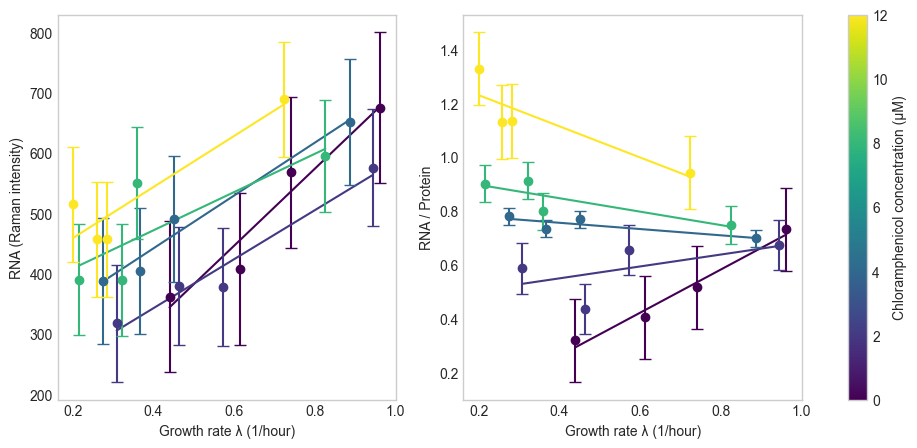

MODEL | Cm 0 µM
  rRNA vs growth        r = 0.989,  R² = 0.978
  rRNA/Protein vs growth r = 0.999,  R² = 0.997
MODEL | Cm 2 µM
  rRNA vs growth        r = 1.000,  R² = 1.000
  rRNA/Protein vs growth r = 0.995,  R² = 0.991
MODEL | Cm 4 µM
  rRNA vs growth        r = 1.000,  R² = 0.999
  rRNA/Protein vs growth r = 0.995,  R² = 0.990
MODEL | Cm 8 µM
  rRNA vs growth        r = 0.999,  R² = 0.999
  rRNA/Protein vs growth r = 0.997,  R² = 0.994
MODEL | Cm 12 µM
  rRNA vs growth        r = 0.962,  R² = 0.926
  rRNA/Protein vs growth r = -0.859,  R² = 0.737


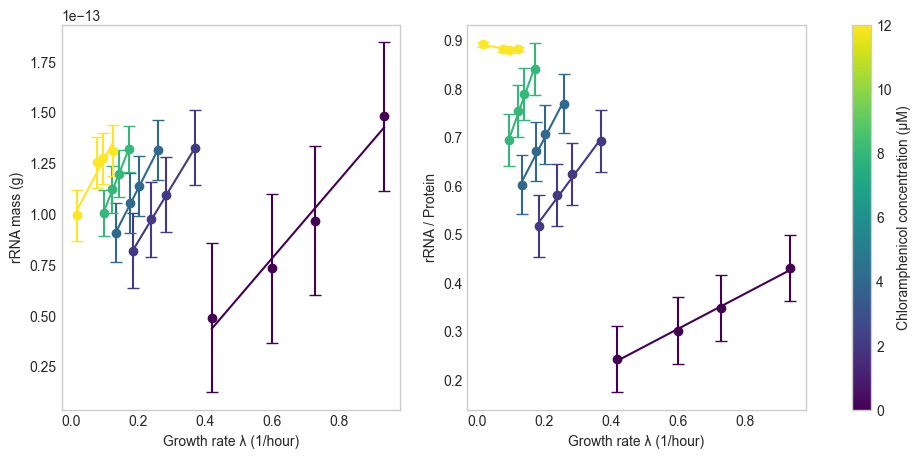

In [ ]:
# COMPLETE ANALYSIS: MODEL + RAMAN

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pyarrow as pa
import pyarrow.ipc as ipc


NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

BURN_IN = 1000.0

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 330.0

GMAX = 12600.0
KGAMMA = 7 * 22000

plt.rcParams['axes.grid'] = False

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()


def compute_rRNA_mass(df):

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    total_nt = r_tot * RIBO_RNA_NT
    return (total_nt / AVOGADRO) * MW_NT


def compute_protein_mass(df):

    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_aa = NR * (r + rmm + rmt + rmq + rmr +
                    zmm + zmt + zmq + zmr)

    non_ribo_aa = NX * (q + et + em)

    total_aa = ribo_aa + non_ribo_aa

    return (total_aa / AVOGADRO) * MW_AA


def compute_total_mass(df):

    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_total = (r + rmm + rmt + rmq + rmr +
                  zmm + zmt + zmq + zmr)

    ribo_mass = NR * ribo_total
    non_ribo  = NX * (q + et + em)

    return ribo_mass + non_ribo


def compute_growth(df, total_mass):

    a = df["a(t)"].to_numpy()

    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return (active * gamma / total_mass) * 60.0


# MODEL 
model_records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"../Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        rRNA = compute_rRNA_mass(df)
        protein = compute_protein_mass(df)
        total_mass = compute_total_mass(df)

        lam = compute_growth(df, total_mass)

        model_records.append({

            "ns": ns,
            "abx": abx,
            "lambda": np.mean(lam),
            "rRNA_mean": np.mean(rRNA),
            "ratio_mean": np.mean(rRNA / protein)

        })

df_model = pd.DataFrame(model_records)

# RAMAN 
rna_df = pd.read_csv("../Data/RamanData/rna.csv")
protein_df = pd.read_csv("../Data/RamanData/protein.csv")
growth_df = pd.read_csv("../Data/RamanData/Raman_growth.csv")

raman_records = []

for nutrient in growth_df["Condition"].unique():

    for abx in ABX_VALUES:

        col = f"Cm{abx}_{nutrient}"

        if col not in rna_df.columns:
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        valid = (RNA > 0) & (PROT > 0)

        RNA = RNA[valid]
        PROT = PROT[valid]

        if len(RNA) == 0:
            continue

        mu = growth_df[
            (growth_df["Condition"] == nutrient) &
            (growth_df["Dose"] == abx)
        ]["Value"].values[0]

        raman_records.append({

            "nutrient": nutrient,
            "abx": abx,
            "lambda": mu,
            "RNA_mean": np.mean(RNA),
            "ratio_mean": np.mean(RNA / PROT)

        })

df_raman = pd.DataFrame(raman_records)

# RAMAN
fig, axes = plt.subplots(1,2, figsize=(12,5))

norm = mcolors.Normalize(vmin=min(ABX_VALUES), vmax=max(ABX_VALUES))
cmap = cm.viridis

for abx in ABX_VALUES:

    subset = df_raman[df_raman["abx"] == abx]

    x = subset["lambda"].values
    y1 = subset["RNA_mean"].values
    y2 = subset["ratio_mean"].values

    if len(x) < 2:
        continue

    color = cmap(norm(abx))

    axes[0].errorbar(x, y1, yerr=np.std(y1), fmt='o', color=color, capsize=4)
    axes[1].errorbar(x, y2, yerr=np.std(y2), fmt='o', color=color, capsize=4)

    slope1, intercept1 = np.polyfit(x, y1, 1)
    slope2, intercept2 = np.polyfit(x, y2, 1)

    r1 = np.corrcoef(x, y1)[0,1]
    r2 = np.corrcoef(x, y2)[0,1]

    print(f"RAMAN | Cm {abx} µM")
    print(f"  RNA vs growth        r = {r1:.3f},  R² = {r1**2:.3f}")
    print(f"  RNA/Protein vs growth r = {r2:.3f},  R² = {r2**2:.3f}")

    x_line = np.linspace(min(x), max(x), 100)

    axes[0].plot(x_line, slope1*x_line + intercept1, color=color)
    axes[1].plot(x_line, slope2*x_line + intercept2, color=color)

axes[0].set_xlabel("Growth rate λ (1/hour)")
axes[0].set_ylabel("RNA (Raman intensity)")

axes[1].set_xlabel("Growth rate λ (1/hour)")
axes[1].set_ylabel("RNA / Protein")

cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes)
cbar.set_label("Chloramphenicol concentration (µM)")

plt.show()

# MODEL

fig, axes = plt.subplots(1,2, figsize=(12,5))

for abx in ABX_VALUES:

    subset = df_model[df_model["abx"] == abx]

    x = subset["lambda"].values
    y1 = subset["rRNA_mean"].values
    y2 = subset["ratio_mean"].values

    if len(x) < 2:
        continue

    color = cmap(norm(abx))

    axes[0].errorbar(x, y1, yerr=np.std(y1), fmt='o', color=color, capsize=4)
    axes[1].errorbar(x, y2, yerr=np.std(y2), fmt='o', color=color, capsize=4)
    # axes[0].errorbar(x, y1, xerr=np.std(x), fmt='o', color=color, capsize=4)
    # axes[1].errorbar(x, y2, xerr=np.std(x), fmt='o', color=color, capsize=4)

    slope1, intercept1 = np.polyfit(x, y1, 1)
    slope2, intercept2 = np.polyfit(x, y2, 1)

    r1 = np.corrcoef(x, y1)[0,1]
    r2 = np.corrcoef(x, y2)[0,1]

    print(f"MODEL | Cm {abx} µM")
    print(f"  rRNA vs growth        r = {r1:.3f},  R² = {r1**2:.3f}")
    print(f"  rRNA/Protein vs growth r = {r2:.3f},  R² = {r2**2:.3f}")

    x_line = np.linspace(min(x), max(x), 100)

    axes[0].plot(x_line, slope1*x_line + intercept1, color=color)
    axes[1].plot(x_line, slope2*x_line + intercept2, color=color)

axes[0].set_xlabel("Growth rate λ (1/hour)")
axes[0].set_ylabel("rRNA mass (g)")

axes[1].set_xlabel("Growth rate λ (1/hour)")
axes[1].set_ylabel("rRNA / Protein")

cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes)
cbar.set_label("Chloramphenicol concentration (µM)")

plt.show()


R² by Antibiotic
abx = 0 µM → R² = 0.9758
abx = 2 µM → R² = 0.9971
abx = 4 µM → R² = 0.9983
abx = 8 µM → R² = 0.9994
abx = 12 µM → R² = 0.9994


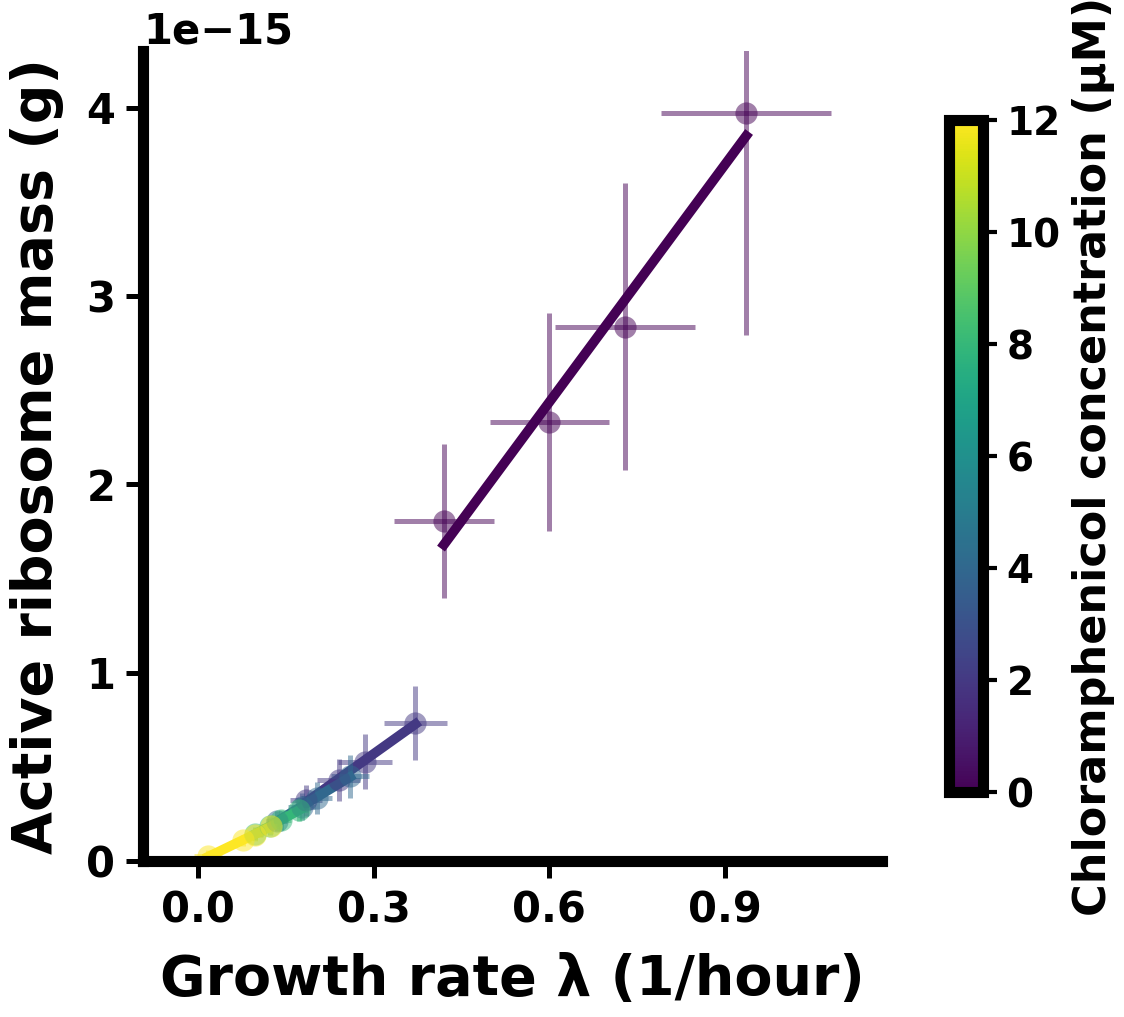

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pyarrow as pa
import pyarrow.ipc as ipc
from matplotlib.ticker import MaxNLocator

plt.style.use("default")
plt.rcParams['font.weight'] = 'bold'
plt.rcParams.update({
    "figure.figsize": (7.2, 6),
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.linewidth": 4.0,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 13,
    "legend.frameon": False,
    "lines.linewidth": 3.5,
    "lines.markersize": 8,
    "errorbar.capsize": 4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05
})

NS_VALUES = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

BURN_IN = 1000.0

NR = 7549.0
NX = 300.0

AVOGADRO = 6.022e23
MW_AA = 110.0

GMAX = 12600.0
KGAMMA = 7 * 22000

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_total_mass(df):
    r = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_total = r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr
    ribo_mass = NR * ribo_total
    non_ribo = NX * (q + et + em)

    return ribo_mass + non_ribo

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return (active * gamma / total_mass) * 60.0

def compute_active_ribosome_mass(df):
    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    active_aa = NR * active
    return (active_aa / AVOGADRO) * MW_AA

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:
        path = f"../Data/ns{int(ns*100):03d}/abx{abx}.arrow"
        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        total_mass = compute_total_mass(df)
        lam = compute_growth(df, total_mass)
        active_mass = compute_active_ribosome_mass(df)

        records.append({
            "ns": ns,
            "abx": abx,
            "lambda_mean": np.mean(lam),
            "lambda_sd": np.std(lam),
            "active_mean": np.mean(active_mass),
            "active_sd": np.std(active_mass)
        })

df_model = pd.DataFrame(records)

def finish_axes(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, labelpad=8, weight='bold')
    ax.set_ylabel(ylabel, labelpad=8, weight='bold')
    ax.tick_params(direction="out", length=6, width=1.8, pad=4)
    ax.margins(x=0.08, y=0.12)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

fig, ax = plt.subplots(figsize=(6,5))
ax.grid(False)

norm = mcolors.Normalize(vmin=min(ABX_VALUES), vmax=max(ABX_VALUES))
cmap = cm.viridis

print("\nR² by Antibiotic")

for abx in ABX_VALUES:
    subset = df_model[df_model["abx"] == abx].sort_values("lambda_mean")

    x = subset["lambda_mean"].values
    y = subset["active_mean"].values
    yerr = subset["active_sd"].values
    xerr = subset["lambda_sd"].values

    if len(x) < 2:
        continue

    color = cmap(norm(abx))

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        color=color,
        elinewidth=1.8,
        capthick=1.8,
        markeredgewidth=0,
        alpha=0.5
    )

    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(np.min(x), np.max(x), 100)
    ax.plot(x_line, slope * x_line + intercept, color=color)

    r = np.corrcoef(x, y)[0, 1]
    print(f"abx = {abx} µM → R² = {r**2:.4f}")

finish_axes(ax, "Growth rate λ (1/hour)", "Active ribosome mass (g)")
ax.set_ylim(0, 4.3e-15)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.08)
cbar.set_label("Chloramphenicol concentration (µM)", fontsize=16, weight='bold')
cbar.ax.tick_params(labelsize=14, width=1.5, length=5)

fig.subplots_adjust(left=0.16, right=0.86, bottom=0.16, top=0.97)
fig.savefig("active_ribosome_mass_vs_growth.png")
plt.show()


=== R² by Antibiotic ===
abx = 0 µM → R² = 0.9758
abx = 2 µM → R² = 0.9971
abx = 4 µM → R² = 0.9983
abx = 8 µM → R² = 0.9994
abx = 12 µM → R² = 0.9994


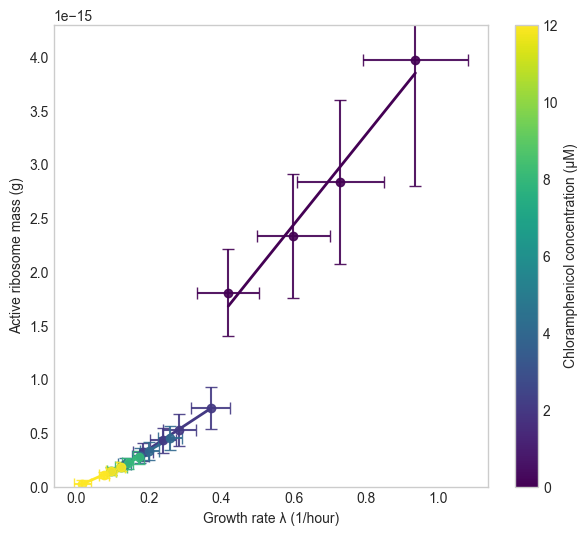

In [ ]:
# ACTIVE RIBOSOME MASS VS GROWTH RATE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pyarrow as pa
import pyarrow.ipc as ipc

plt.rcParams["axes.grid"] = False 

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

BURN_IN = 1000.0

NR = 7549.0
NX = 300.0

AVOGADRO = 6.022e23
MW_AA = 110.0

GMAX = 12600.0
KGAMMA = 7 * 22000


def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# MODEL FUNCTIONS

def compute_total_mass(df):

    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_total = (r + rmm + rmt + rmq + rmr +
                  zmm + zmt + zmq + zmr)

    ribo_mass = NR * ribo_total
    non_ribo  = NX * (q + et + em)

    return ribo_mass + non_ribo

def compute_growth(df, total_mass):

    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return (active * gamma / total_mass) * 60.0

def compute_active_ribosome_mass(df):

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    active_aa = NR * active
    return (active_aa / AVOGADRO) * MW_AA

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"../Data/ns{int(ns*100):03d}/abx{abx}.arrow"
        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        total_mass = compute_total_mass(df)
        lam = compute_growth(df, total_mass)
        active_mass = compute_active_ribosome_mass(df)

        records.append({
            "ns": ns,
            "abx": abx,
            "lambda_mean": np.mean(lam),
            "lambda_sd": np.std(lam),
            "active_mean": np.mean(active_mass),
            "active_sd": np.std(active_mass)
        })

df_model = pd.DataFrame(records)


fig, ax = plt.subplots(figsize=(7,6))
ax.grid(False)

norm = mcolors.Normalize(vmin=min(ABX_VALUES), vmax=max(ABX_VALUES))
cmap = cm.viridis

print("\n=== R² by Antibiotic ===")

for abx in ABX_VALUES:

    subset = df_model[df_model["abx"] == abx]

    x = subset["lambda_mean"].values
    y = subset["active_mean"].values
    xerr = subset["lambda_sd"].values
    yerr = subset["active_sd"].values

    if len(x) < 2:
        continue

    color = cmap(norm(abx))

    ax.errorbar(
        x, y,
        xerr=xerr,
        yerr=yerr,
        fmt='o',
        capsize=4,
        color=color,
        alpha=0.9
    )

    # Regression
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(min(x), max(x), 100)
    ax.plot(x_line, slope*x_line + intercept,
            color=color, linewidth=2)

    r = np.corrcoef(x, y)[0,1]
    print(f"abx = {abx} µM → R² = {r**2:.4f}")

ax.set_xlabel("Growth rate λ (1/hour)")
ax.set_ylabel("Active ribosome mass (g)")
# ax.set_title("Active Ribosome Mass vs Growth")
ax.set_ylim(0,4.3*1e-15)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
fig.colorbar(sm, ax=ax, label="Chloramphenicol concentration (µM)")

plt.show()

               0         2         4         8         12
gly      0.289333  0.383736  0.537095  0.650143  0.781489
glu      0.495203  0.385832  0.518591  0.481788  0.654838
caa_gly  0.351680  0.514298  0.567110  0.657143  0.654028
caa_glu  0.676843  0.239632  0.726312  0.752360  0.537909


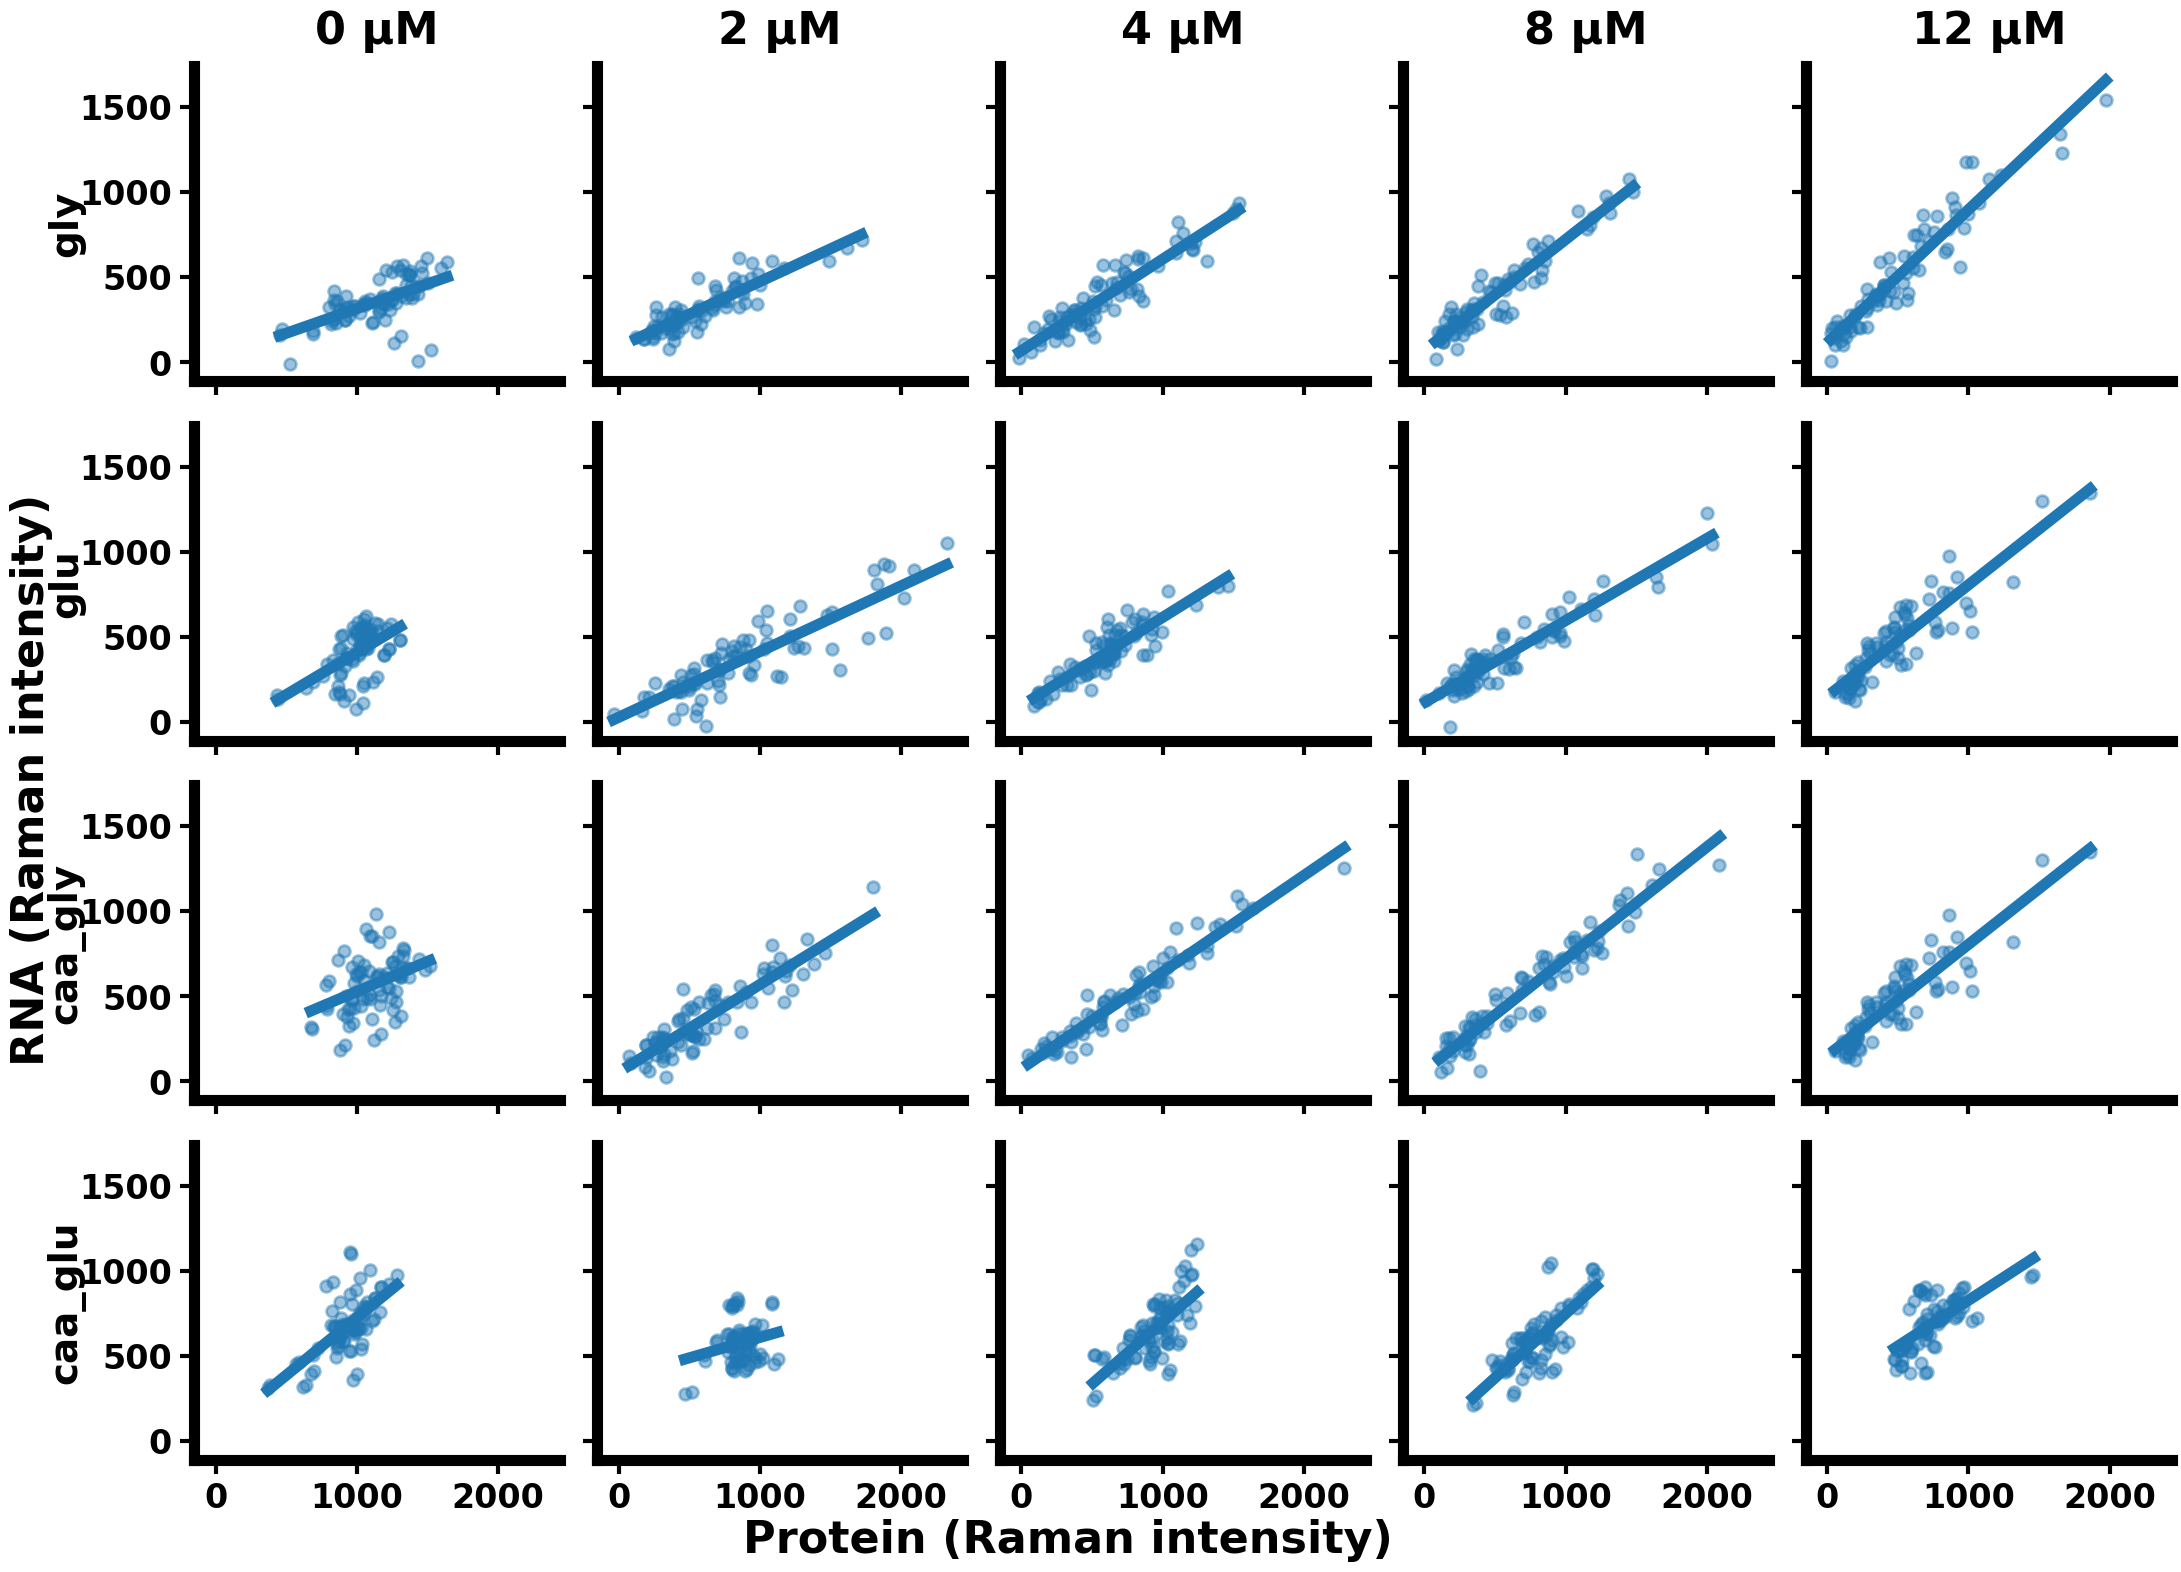

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams['font.weight'] = 'bold'
plt.rcParams.update({
    "figure.figsize": (11.5, 8.5),
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "axes.linewidth": 4,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "lines.linewidth": 4,
    "lines.markersize": 6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05
})

rna_df = pd.read_csv("../Data/RamanData/rna.csv")
protein_df = pd.read_csv("../Data/RamanData/protein.csv")

nutrients = ["gly", "glu", "caa_gly", "caa_glu"]
cm_levels = [0, 2, 4, 8, 12]

pretty_nutrients = {
    "gly": "gly",
    "glu": "glu",
    "caa_gly": "caa_gly",
    "caa_glu": "caa_glu"
}

slope_matrix = np.zeros((len(nutrients), len(cm_levels)))

fig, axes = plt.subplots(
    len(nutrients),
    len(cm_levels),
    figsize=(11.5, 8.5),
    sharex=True,
    sharey=True
)

for i, nutrient in enumerate(nutrients):
    for j, cm in enumerate(cm_levels):
        col = f"Cm{cm}_{nutrient}"
        ax = axes[i, j]

        if col not in rna_df.columns or col not in protein_df.columns:
            slope_matrix[i, j] = np.nan
            ax.set_visible(False)
            continue

        RNA = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        N = min(len(RNA), len(PROT))
        RNA = RNA[:N]
        PROT = PROT[:N]

        if len(PROT) > 2:
            coef = np.polyfit(PROT, RNA, 1)
            slope_matrix[i, j] = coef[0]

            x_grid = np.linspace(PROT.min(), PROT.max(), 100)
            y_pred = np.polyval(coef, x_grid)
        else:
            slope_matrix[i, j] = np.nan
            x_grid = None
            y_pred = None

        ax.scatter(PROT, RNA, s=18, alpha=0.45)

        if x_grid is not None:
            ax.plot(x_grid, y_pred)

        ax.tick_params(direction="out", length=5, width=1.5, pad=3)

        if i == 0:
            ax.set_title(f"{cm} µM", pad=8, weight='bold')

        if j == 0:
            ax.text(
                -0.35, 0.5, pretty_nutrients[nutrient],
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=14,
                weight='bold'
            )

df_slopes = pd.DataFrame(
    slope_matrix,
    index=nutrients,
    columns=cm_levels
)

print(df_slopes)

fig.supxlabel("Protein (Raman intensity)", y=0.04, fontsize=16, weight='bold')
fig.supylabel("RNA (Raman intensity)", x=0.04, fontsize=16, weight='bold')

fig.subplots_adjust(left=0.12, right=0.98, bottom=0.10, top=0.92, wspace=0.10, hspace=0.14)
fig.savefig("raman_rna_protein_scatter_grid.png")
plt.show()

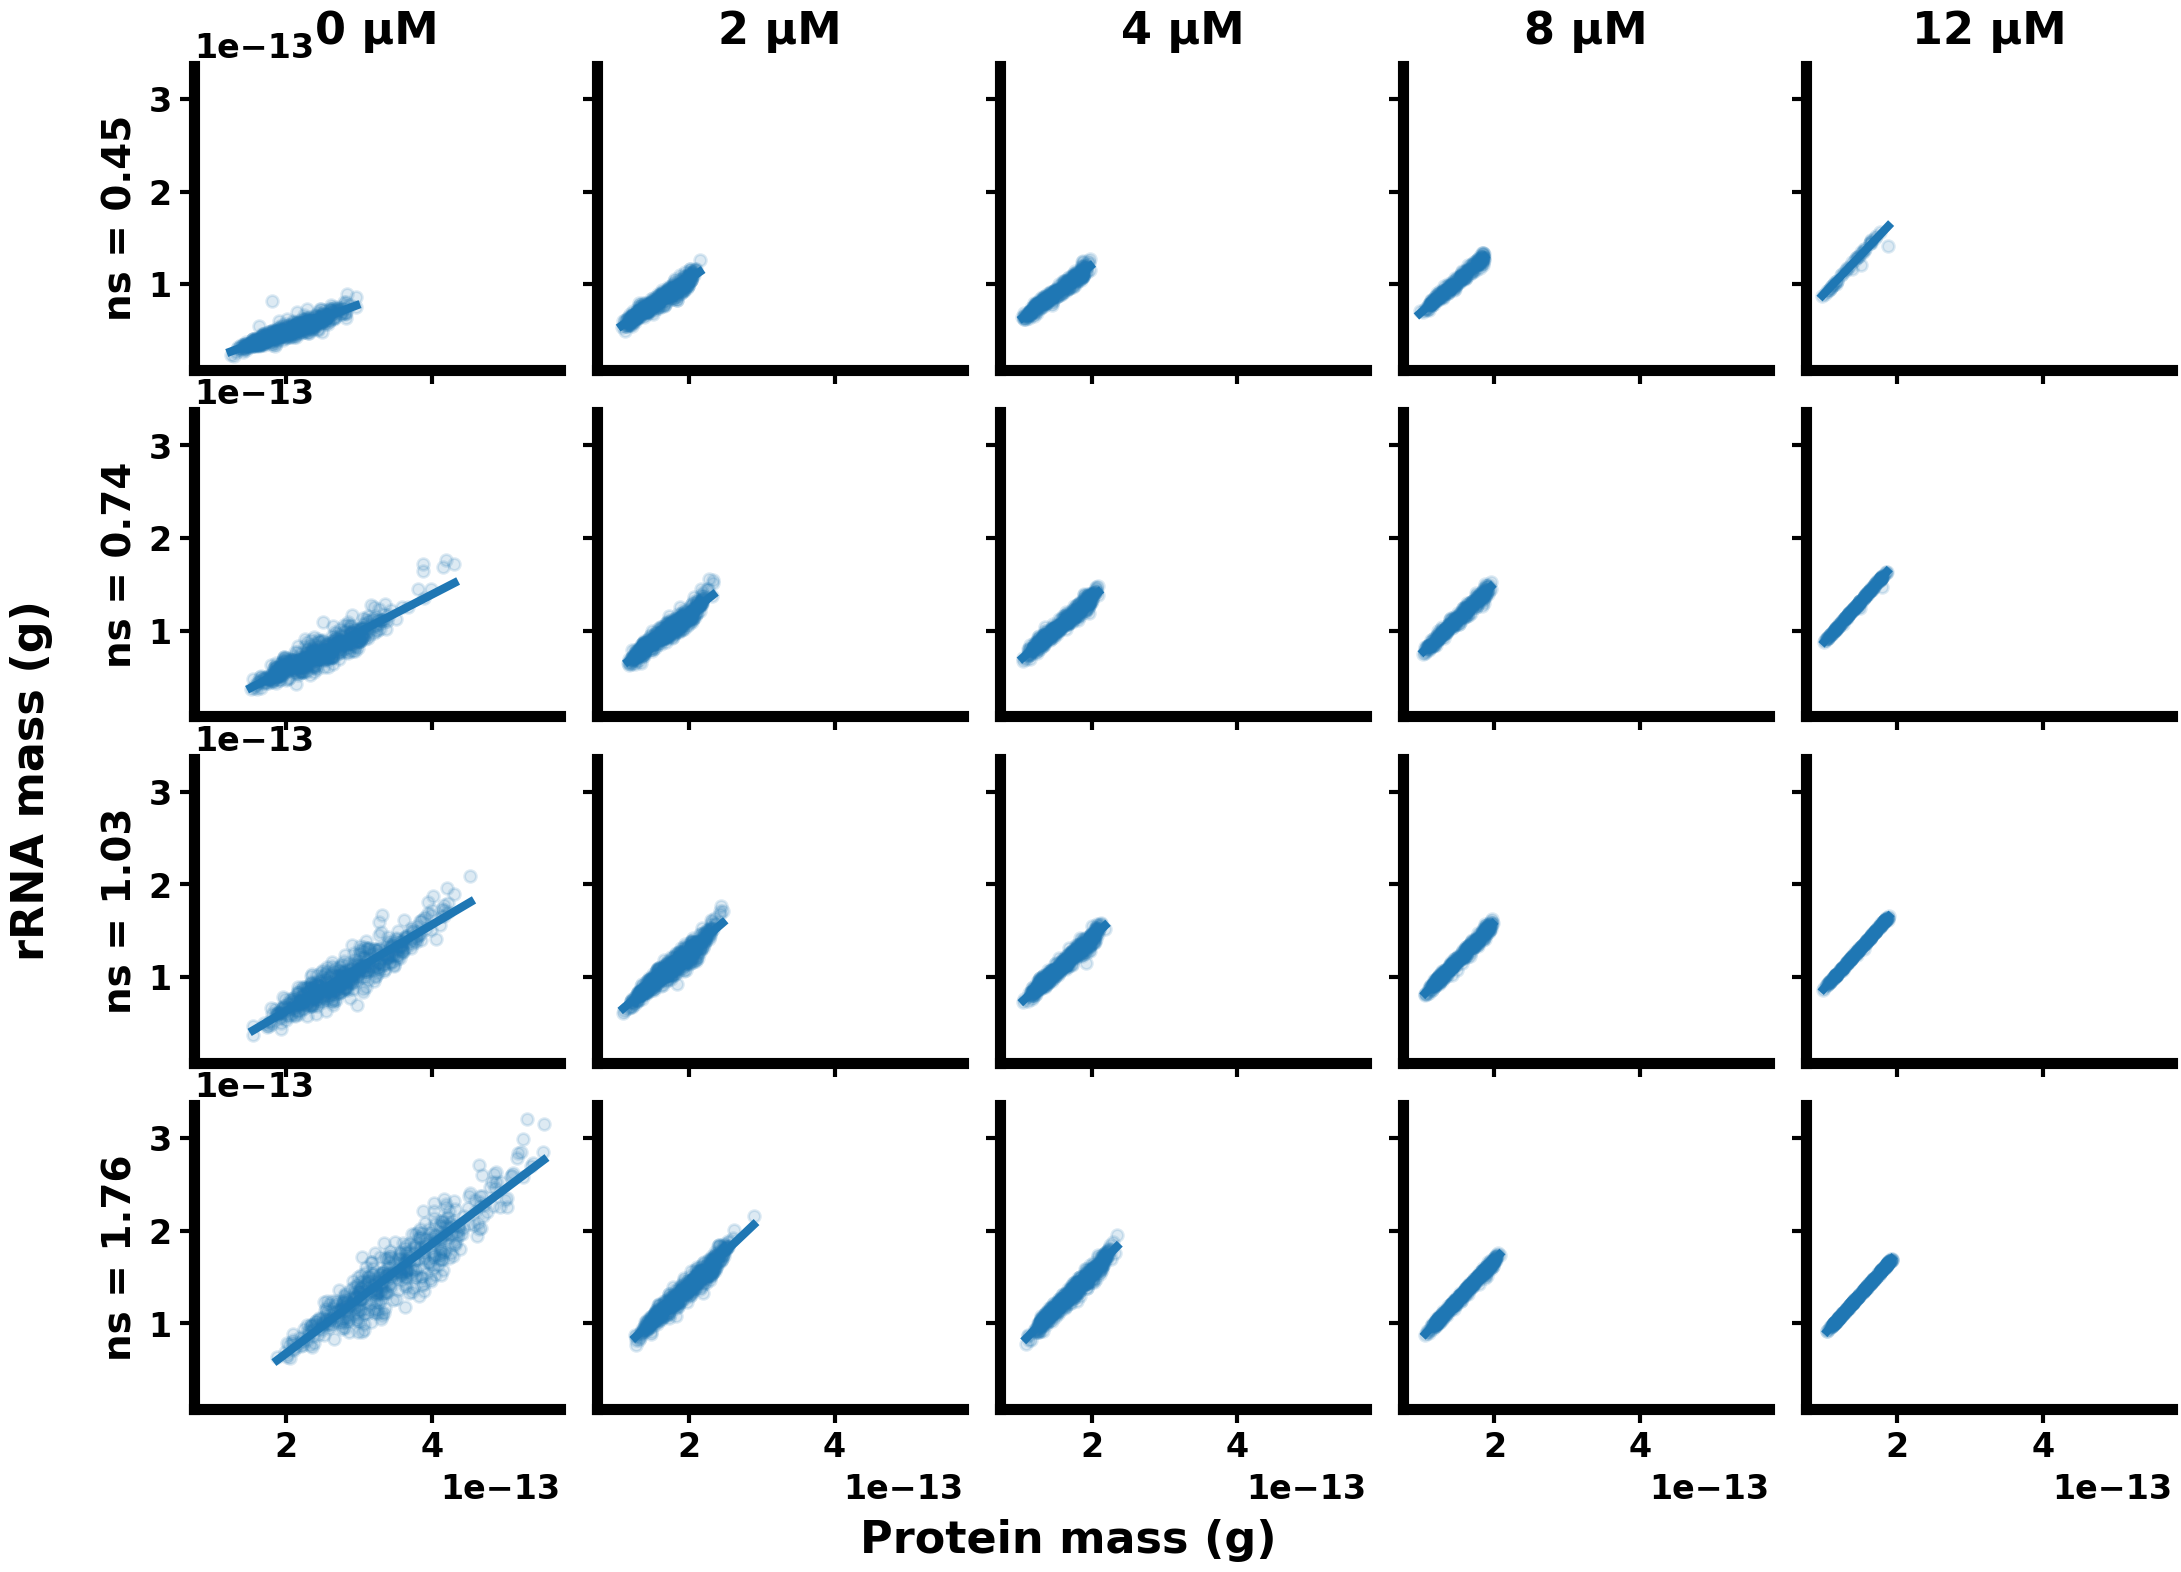

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

plt.style.use("default")

plt.rcParams['font.weight'] = 'bold'
plt.rcParams.update({
    "figure.figsize": (11.5, 8.5),
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "axes.linewidth": 4,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "lines.linewidth": 3,
    "lines.markersize": 6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05
})

NS_VALUES = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

BURN_IN = 1000.0
GUARD_FRAC = 0.1

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 330.0

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    return np.where(dslope == -2)[0] + 1

def sample_one_per_cycle(total_mass, guard_frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass) - 1]))

    sample_indices = []

    for i in range(len(div_idx) - 1):
        start = div_idx[i]
        end = div_idx[i + 1]
        L = end - start

        if L < 10:
            continue

        g = int(guard_frac * L)
        lo = start + g
        hi = end - g

        if hi > lo:
            sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)

def compute_total_protein_mass(df):
    r = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_aa = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_aa = NX * (q + et + em)
    total_aa = ribo_aa + non_ribo_aa

    return (total_aa / AVOGADRO) * MW_AA

def compute_rRNA_mass(df):
    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_nt = r_tot * RIBO_RNA_NT
    return (rRNA_nt / AVOGADRO) * MW_NT

fig, axes = plt.subplots(
    len(NS_VALUES),
    len(ABX_VALUES),
    figsize=(11.5, 8.5),
    sharex=True,
    sharey=True
)

for i, ns in enumerate(NS_VALUES):
    for j, abx in enumerate(ABX_VALUES):
        path = f"../Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        protein_mass = compute_total_protein_mass(df)
        rRNA_mass = compute_rRNA_mass(df)

        idx = sample_one_per_cycle(protein_mass, guard_frac=GUARD_FRAC)

        protein_mass = protein_mass[idx]
        rRNA_mass = rRNA_mass[idx]

        ax = axes[i, j]

        ax.scatter(protein_mass, rRNA_mass, s=18, alpha=0.15)

        if len(protein_mass) > 2:
            coef = np.polyfit(protein_mass, rRNA_mass, 1)
            x_grid = np.linspace(protein_mass.min(), protein_mass.max(), 100)
            y_pred = np.polyval(coef, x_grid)
            ax.plot(x_grid, y_pred)

        ax.tick_params(direction="out", length=5, width=1.5, pad=3)
        ax.grid(False)

        if i == 0:
            ax.set_title(f"{abx} µM", pad=8, weight='bold')

        if j == 0:
            ax.text(
                -0.2, 0.5, f"ns = {ns}",
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=14,
                weight='bold'
            )

fig.supxlabel("Protein mass (g)", y=0.04, fontsize=16, weight='bold')
fig.supylabel("rRNA mass (g)", x=0.04, fontsize=16, weight='bold')

fig.subplots_adjust(left=0.12, right=0.98, bottom=0.13, top=0.92, wspace=0.10, hspace=0.14)
fig.savefig("model_rrna_vs_protein_grid.png")
plt.show()